In [1]:
import pandas as pd 
from bpepi.Modules import fg_torch as fg #pytorch version
from src.helpers.sim_graph import *
from src.utils.metrics import *
from src.helpers.pipeline_helpers import *
import numpy as np
from collections import defaultdict
import itertools
import copy
from tqdm import tqdm
from src.utils.sensor_logger import SensorLogger

from src.Analysis.gen import generate_contacts, simulate_one_detSIR

In [ ]:
Nsim = 5
deltas = [0.1]
lambdas = [0.3]
graph_type = "rrg" #["er", "rrg", "ba"]
rhos = np.arange(0, 1.1, 0.1)
N = 5000
T_max = 20
d=3

In [4]:
from src.algorithms.static_selection import random_selection, deg_centrality_selection, betweenness_centrality_selection, page_rank_selection, closeness_selection    

results_df = pd.DataFrame(columns=["method", "metric", "graph", "rho", "delta", "lambda", "sim", "O", "MO", "O_tilde", "MO_tilde", "SE", "MSE", "rank", "precision", "recall", "f1"])

for sim in tqdm(range(Nsim)):
    print(f"\n=== Sim {sim} ===")
    for delta, lam in itertools.product(deltas, lambdas):
        G = generate_graph(N, d, kind=graph_type)
        add_infection_proba(G=G, lam=lam)
        contacts = generate_contacts(G=G, lambda_=lam, T=T_max)
        snn = simulate_one_detSIR(G=G, s_type = "delta", S = delta, mask = ["SI"], T_max=T_max)

        print("infection done")
        # if method is static, we can directly loop over rhos - no metrics needed for selection
        bp_fg = fg.FactorGraph(N, T_max, contacts, [], delta)
        print("empty bp done")

        for rho in tqdm(rhos):
            print("in rho loop")
            selected_sensors = random_selection(bp_base = bp_fg, rho_max=rho, m=None, G=G)
            print("Evaluating sensors...")
            result = evaluate_sensors(selected_sensors, bp_fg, status_nodes=snn)
            result.update({
                "method": "random",
                "metric": "N/A",
                "delta": delta,
                "lambda": lam,
                "rho": rho,
                "sim": sim,
                "graph": graph_type
            })
            results_df.loc[len(results_df)] = result

  0%|          | 0/5 [00:00<?, ?it/s]


=== Sim 0 ===
infection done
empty bp done


in rho loop
Evaluating sensors...


in rho loop
Evaluating sensors...


in rho loop
Evaluating sensors...


...

in rho loop
Evaluating sensors...


in rho loop
Evaluating sensors...


in rho loop
Evaluating sensors...


in rho loop
Evaluating sensors...


100%|██████████| 5/5 [03:37<00:00, 43.40s/it]


List of method_metric combinations:  <StringArray>
['random_N/A']
Length: 1, dtype: str


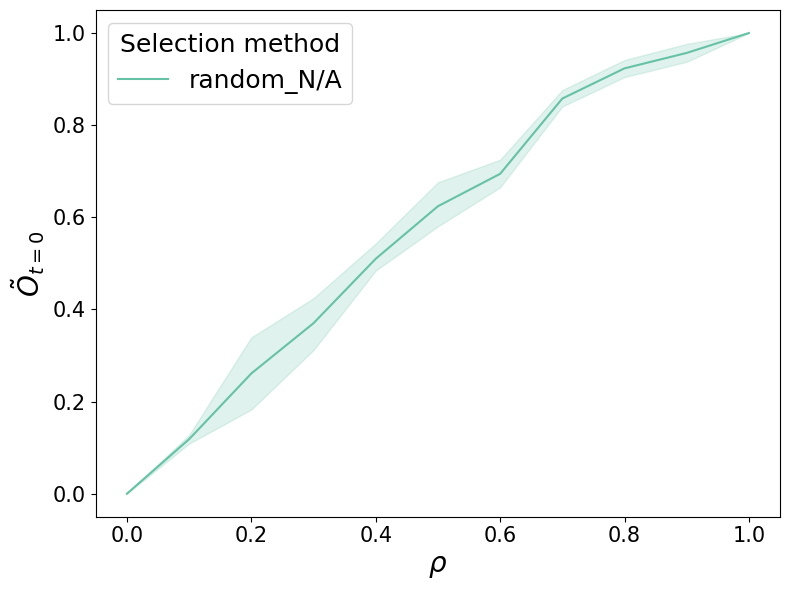

In [5]:
from src.helpers.plot_helpers import plot_comparison


delta = deltas[0]
SAVE_PATH = f"results_new/comparison_{graph_type}_delta{delta}.png"
plot_comparison(results_df, eval_metric="O_tilde", delta=delta, save=True, title=None, save_path=SAVE_PATH)
